**MAGIC GAMMA TELESCOPE MACHINE LEARNING PROJECT**

Project Title: Classifying Cosmic Particle Signals using Supervised Machine Learning: A Comparative Study on the MAGIC Gamma Telescope Dataset.

Core Objective: Analyze the MAGIC Gamma Telescope dataset and build an optimized binary classification model to accurately distinguish between the following particle event classes:

Gamma Rays (g) – Signals generated by high-energy gamma particles captured by the telescope
Hadron Events (h) – Background noise caused by cosmic hadrons that must be filtered out


**Key question solved in this project**
1. What is the structure and quality of the dataset?
2. Is the dataset balanced or imbalanced?
3. Which telescope signal features are most informative?
5. Are there redundant or highly correlated variables?
6. How do feature distributions differ between Gamma and Hadron events?
7. Which machine learning model performs best for classification?
8. How accurate is the final model on unseen test data?


In [5]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE


**SECTION-A: LOAD THE DATASET**

In [6]:
# Load dataset
df = pd.read_csv("magic04_gamma.csv")

# Drop unwanted index column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Convert target labels into numeric form
# Gamma = 0, Hadron = 1
df["class"] = df["class"].astype(str).str.strip().str.lower().map({"g":0, "h":1})

# Show first 5 rows
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,0
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,0
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,0
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,0
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,0


In [7]:
# Create compact dataset summary table
summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_values": df.isna().sum().values,
    "missing_percentage": (df.isna().mean() * 100).round(2).values,
    "unique_values": df.nunique().values
})

summary

,column,dtype,missing_values,missing_percentage,unique_values
0,fLength,float64,0,0.0,18643
1,fWidth,float64,0,0.0,18200
2,fSize,float64,0,0.0,7228
3,fConc,float64,0,0.0,6410
4,fConc1,float64,0,0.0,4421
5,fAsym,float64,0,0.0,18704
6,fM3Long,float64,0,0.0,18693
7,fM3Trans,float64,0,0.0,18390
8,fAlpha,float64,0,0.0,17981
9,fDist,float64,0,0.0,18437


**SECTION B: Target Variable Analysis**
Distribution of Gamma (g) vs Hadron (h)

The distribution of classes affects model performance. If the dataset is imbalanced, the model may become biased toward the class with more samples.

As a result, predictions for the minority class may be less accurate. Checking class balance helps build a fair and reliable model.

    class  count  percentage
0   Gamma  12332       64.84
1  Hadron   6688       35.16


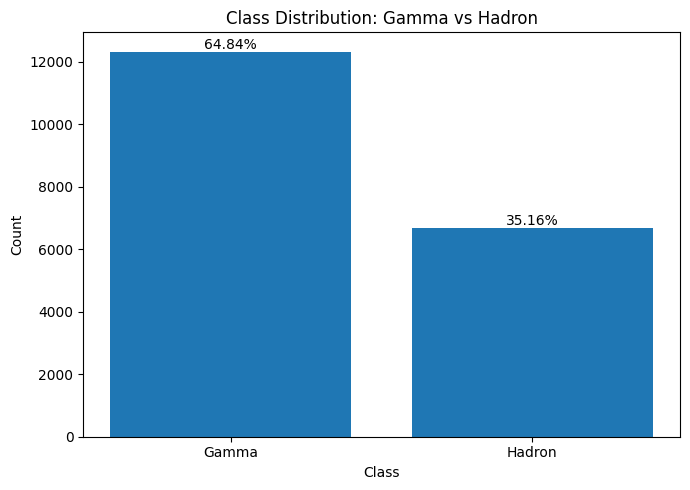

In [8]:

# TARGET VARIABLE ANALYSIS

# Create class count and percentage summary table
counts = df["class"].value_counts().sort_index()

class_distribution = pd.DataFrame({
    "class": ["Gamma", "Hadron"],
    "count": [counts.get(0, 0), counts.get(1, 0)]
})

class_distribution["percentage"] = (
    class_distribution["count"] / len(df) * 100
).round(2)

print(class_distribution)


# Plot class distribution
plt.figure(figsize=(7, 5))
bar_plot = plt.bar(
    class_distribution["class"],
    class_distribution["count"]
)

plt.title("Class Distribution: Gamma vs Hadron")
plt.xlabel("Class")
plt.ylabel("Count")

# Add percentage labels above bars
for bar, pct in zip(bar_plot, class_distribution["percentage"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("plots/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

We can see that percentage of g: 65% and percentage of h is 35%. So there exists a class imbalance.

**Handling Class Imbalance**

The dataset shows a moderate class imbalance. Although it is not extreme, it may cause the model to favor the majority class.

This problem can be handled using techniques such as Random Oversampling or SMOTE.

In this project, we use **SMOTE** to balance the training data before model building.


**SECTION C: Feature Distribution**


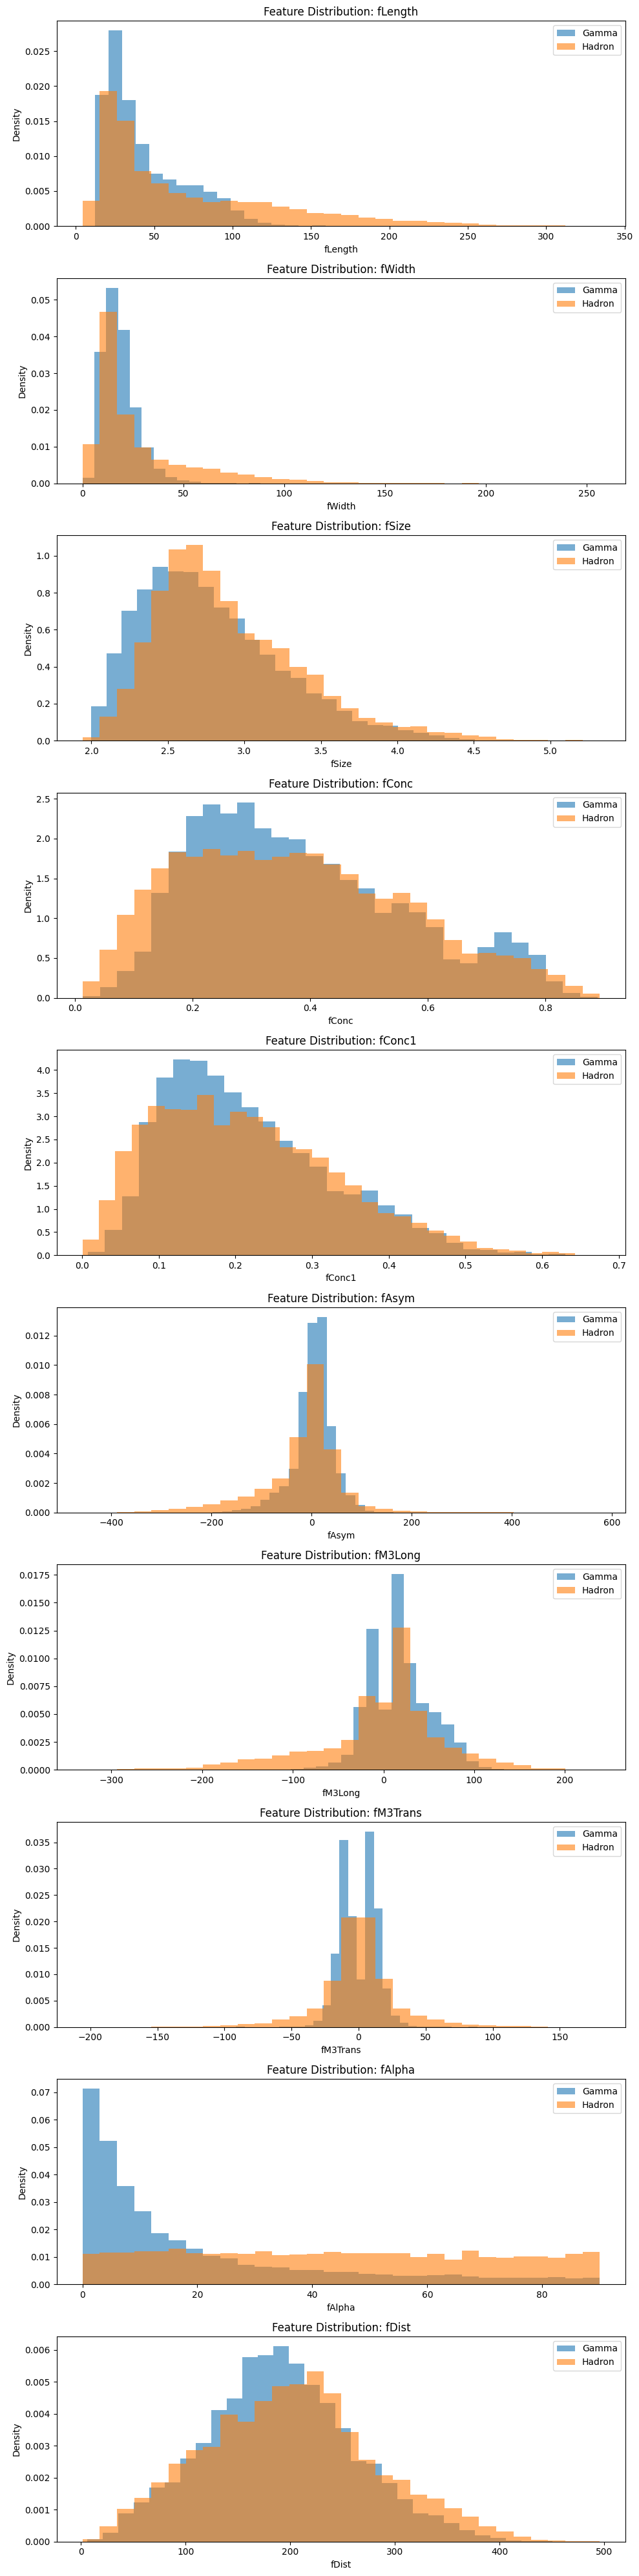

In [9]:

# Select all feature columns except target
feature_columns = [col for col in df.columns if col != "class"]

# Create subplot grid
fig, axes = plt.subplots(
    len(feature_columns),
    1,
    figsize=(10, 4 * len(feature_columns))
)

# If only one feature exists, convert axes into list
if len(feature_columns) == 1:
    axes = [axes]

# Plot histogram for each feature
for ax, col in zip(axes, feature_columns):
    ax.hist(
        df[df["class"] == 0][col],
        bins=30,
        alpha=0.6,
        density=True,
        label="Gamma"
    )
    ax.hist(
        df[df["class"] == 1][col],
        bins=30,
        alpha=0.6,
        density=True,
        label="Hadron"
    )

    ax.set_title(f"Feature Distribution: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.savefig("plots/feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

SECTION C: Outlier Detection:
1. Boxplot(Visual)
2. IQR(Inter Quartile Range)

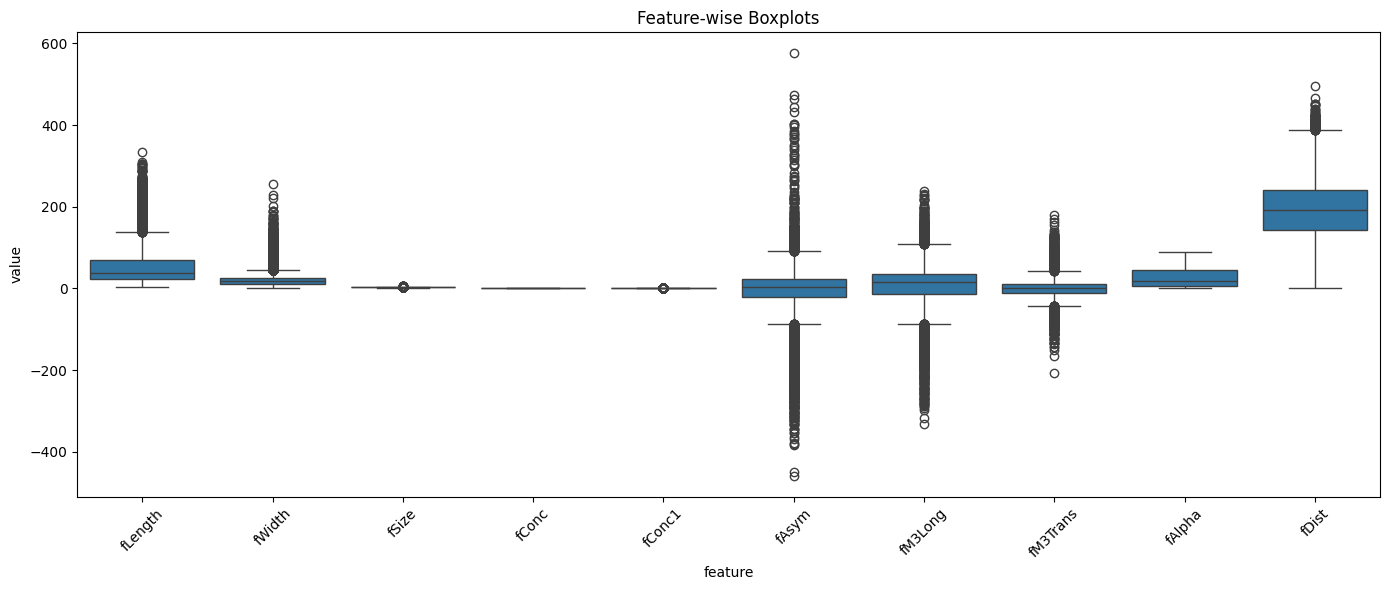

    feature       q1       q3     iqr  lower_bound  upper_bound  \
0   fLength   24.336   70.122  45.786      -44.343      138.801   
1    fWidth   11.864   24.739  12.876       -7.450       44.053   
2     fSize    2.477    3.102   0.624        1.540        4.038   
3     fConc    0.236    0.504   0.268       -0.166        0.906   
4    fConc1    0.128    0.285   0.157       -0.107        0.520   
5     fAsym  -20.587   24.064  44.650      -87.562       91.039   
6   fM3Long  -12.843   35.838  48.681      -85.864      108.859   
7  fM3Trans  -10.849   10.946  21.796      -43.543       43.640   
8    fAlpha    5.548   45.884  40.336      -54.956      106.387   
9     fDist  142.492  240.564  98.072       -4.615      387.671   

   outlier_count  outlier_percentage  
0            971               5.105  
1           1546               8.128  
2            367               1.930  
3              0               0.000  
4            150               0.789  
5           1781            

In [10]:
# Boxplots help visually inspect skewness and extreme values.
feature_df = df.drop(columns=["class"])
melted_df = feature_df.melt(var_name="feature", value_name="value")

plt.figure(figsize=(14, 6))
sns.boxplot(data=melted_df, x="feature", y="value")
plt.xticks(rotation=45)
plt.title("Feature-wise Boxplots")
plt.tight_layout()
plt.savefig("plots/feature_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

# IQR-based outlier summary table
outlier_rows = []

for col in feature_df.columns:
    q1 = feature_df[col].quantile(0.25)
    q3 = feature_df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = ((feature_df[col] < lower_bound) | (feature_df[col] > upper_bound)).sum()
    outlier_percentage = round((outlier_count / len(feature_df)) * 100, 3)

    outlier_rows.append({
        "feature": col,
        "q1": round(q1, 3),
        "q3": round(q3, 3),
        "iqr": round(iqr, 3),
        "lower_bound": round(lower_bound, 3),
        "upper_bound": round(upper_bound, 3),
        "outlier_count": outlier_count,
        "outlier_percentage": outlier_percentage
    })

outlier_summary = pd.DataFrame(outlier_rows)

print(outlier_summary)

**SECTION C: Feature Relationships (Correlation Analysis)**

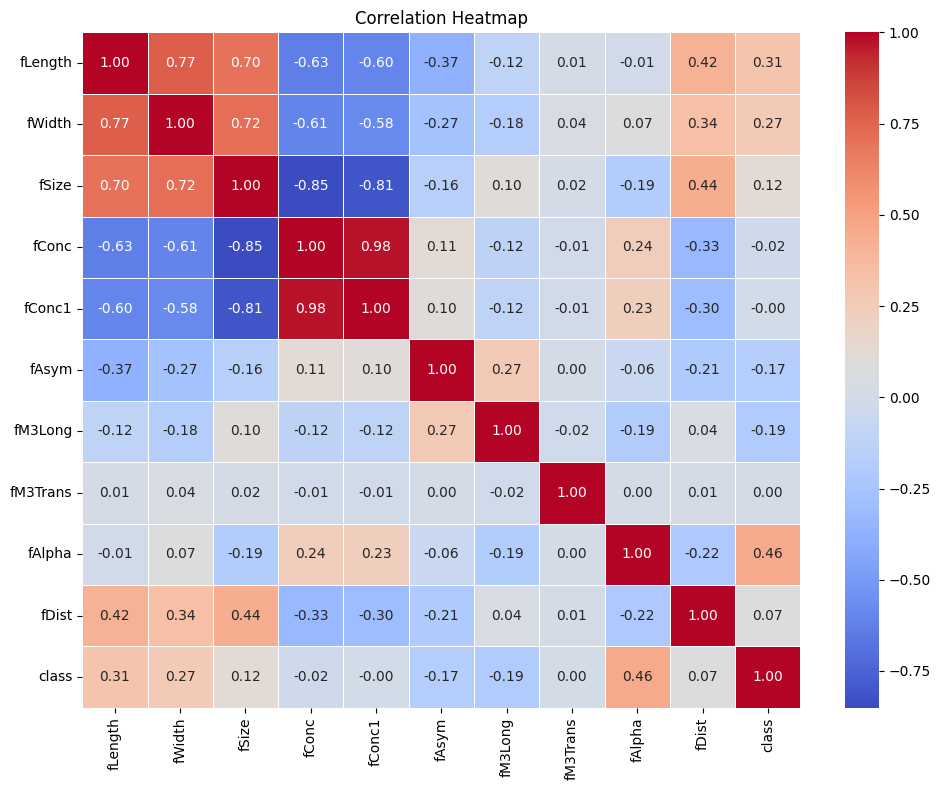

In [11]:

# Compute correlation matrix
correlation_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("plot/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


Correlation analysis revealed strong relationships between several features, particularly between fConc and fConc1 (0.98), indicating redundancy. Additionally, features such as fLength, fWidth, and fSize exhibited strong inter-correlation, suggesting they capture similar characteristics. Among all features, fSize, fLength, and fWidth showed the highest correlation with the target variable, indicating strong predictive potential. Weakly correlated features such as fM3Trans may contribute independent information to the model.

Which means I can remove fconc1 or fconc. As they are redundent.


After Doing the EDA we found out the following:
1. There exists a class imbalance Percent of g:64.84% and Percentage of g: 36%.
2. From the box plot we found out that the range of these features are very large so we need to scale them.
3. From the heat map we found out that some features like fconc and fconc1 are redundent are we can drop one.



The next step of the pipeline is to divide the dataset into train, validate and test datasets. The entire dataset was then divided into 70%train, 15% validate and 15% tests dataset.

Stratified split was prefered because it preserves the ratio of train,test and validate datasets among each split.

In [12]:

# Split dataset into input features (X) and target variable (y)
X = df.drop("class", axis=1)
y = df["class"]

# Perform stratified split:
# 70% Training Data
# 15% Validation Data
# 15% Test Data

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# Display dataset shapes
print(f"Training set shape   : {X_train.shape}")
print(f"Validation set shape : {X_val.shape}")
print(f"Test set shape       : {X_test.shape}")



Training set shape   : (13314, 10)
Validation set shape : (2853, 10)
Test set shape       : (2853, 10)


In [13]:
# Handling class imbalance
smote = SMOTE(random_state=42)

# Display dataset shapes before SMOTE
print("Before SMOTE")
print(f"Training set shape   : {X_train.shape}")
print(f"Validation set shape : {X_val.shape}")
print(f"Test set shape       : {X_test.shape}")

X_train, y_train = smote.fit_resample(X_train, y_train)

# Display dataset shapes after SMOTE
print("\nAfter SMOTE")
print(f"Resampled training set shape : {X_train.shape}")
print(f"Resampled target shape       : {y_train.shape}")

Before SMOTE
Training set shape   : (13314, 10)
Validation set shape : (2853, 10)
Test set shape       : (2853, 10)

After SMOTE
Resampled training set shape : (17264, 10)
Resampled target shape       : (17264,)


In [14]:
# StandardScaler is applied because some features have
# large value ranges and different scales.

scaler = StandardScaler()

# Fit only on training data to avoid data leakage
X_train = scaler.fit_transform(X_train)

# Apply same transformation to validation and test sets
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Confirm scaling results
print("Mean of scaled training data :", round(X_train.mean(), 4))
print("Std of scaled training data  :", round(X_train.std(), 4))

Mean of scaled training data : 0.0
Std of scaled training data  : 1.0


SECTION : BUILD MODELS

In [15]:
# Building models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Gaussian Naive Bayes": GaussianNB(),

    "Linear SVM": LinearSVC(
        random_state=42,
        max_iter=5000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "Voting Classifier": VotingClassifier(
        estimators=[
            ("lr", LogisticRegression()),
            ("svm", SVC(probability=True)),
            ("rf", RandomForestClassifier())
        ],
        voting="soft"
    )
}

print("Models built successfully:")
for model_name in models.keys():
    print("-", model_name)

Models built successfully:
- Logistic Regression
- Gaussian Naive Bayes
- Linear SVM
- Decision Tree
- Random Forest
- Gradient Boosting
- Voting Classifier


**SECTION D: MODEL EVALUATION ON VALIDATION DATA**

In [16]:

# MODEL EVALUATION ON VALIDATION DATA


# Train each model and evaluate on validation data
rows = []
fitted_models = {}

for model_name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Predict class labels
    y_pred = model.predict(X_val)

    # Predict probabilities for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_val)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_val)
    else:
        y_prob = y_pred

    # Store evaluation metrics
    rows.append({
        "model": model_name,
        "accuracy": round(accuracy_score(y_val, y_pred), 4),
        "precision": round(precision_score(y_val, y_pred), 4),
        "recall": round(recall_score(y_val, y_pred), 4),
        "f1_score": round(f1_score(y_val, y_pred), 4),
        "roc_auc": round(roc_auc_score(y_val, y_prob), 4)
    })

    # Save fitted model
    fitted_models[model_name] = model

# Create results dataframe
results_df = pd.DataFrame(rows).sort_values(
    by=["f1_score", "roc_auc", "accuracy"],
    ascending=False
)

# Display results
print("Validation Results:")
print(results_df)

# Save results table
results_df.to_csv("plots/model_validation_results.csv", index=False)

Validation Results:
                  model  accuracy  precision  recall  f1_score  roc_auc
4         Random Forest    0.8682     0.8083  0.8195    0.8139   0.9316
6     Voting Classifier    0.8654     0.8025  0.8185    0.8105   0.9248
5     Gradient Boosting    0.8605     0.7951  0.8126    0.8037   0.9178
3         Decision Tree    0.7978     0.6951  0.7567    0.7246   0.7884
0   Logistic Regression    0.7936     0.7002  0.7218    0.7108   0.8397
2            Linear SVM    0.7964     0.7102  0.7109    0.7105   0.8399
1  Gaussian Naive Bayes    0.7178     0.6634  0.4008    0.4997   0.7563


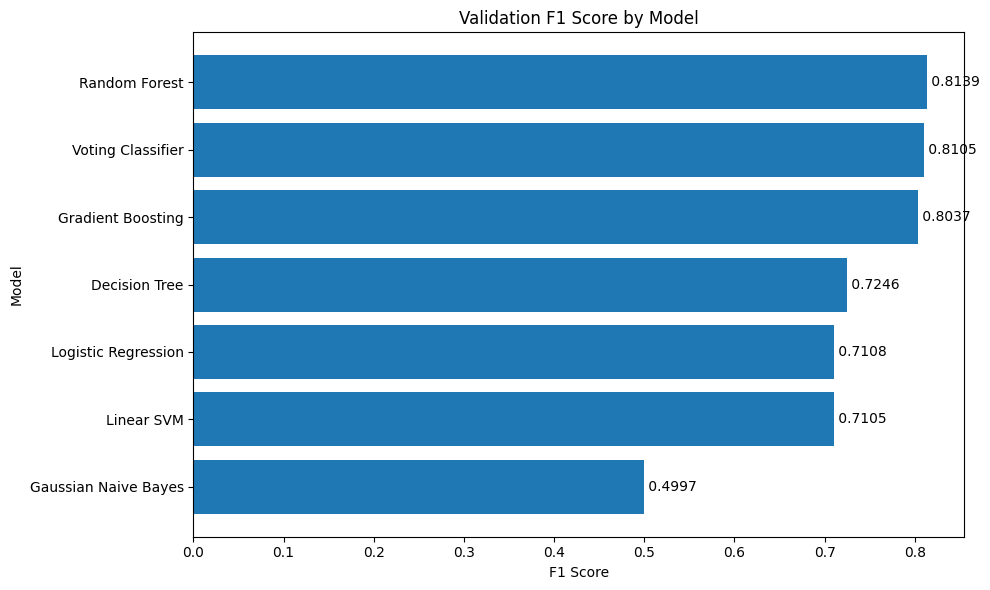

In [32]:

# SECTION M: MODEL COMPARISON VISUALIZATION

plt.figure(figsize=(10, 6))
plot_df = results_df.sort_values(by="f1_score")
plt.barh(plot_df["model"], plot_df["f1_score"])

plt.title("Validation F1 Score by Model")
plt.xlabel("F1 Score")
plt.ylabel("Model")

# Add score labels on bars
for i, v in enumerate(plot_df["f1_score"]):
    plt.text(v, i, f" {v:.4f}", va="center")

plt.tight_layout()
plt.savefig("plots/validation_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:

# SECTION: FINAL TEST EVALUATION

# Select best model based on validation F1 score
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]

print(f"Best Model Selected: {best_model_name}")

# Predict on unseen test data
y_test_pred = best_model.predict(X_test)

# Probability scores for ROC-AUC
if hasattr(best_model, "predict_proba"):
    y_test_prob = best_model.predict_proba(X_test)[:, 1]
elif hasattr(best_model, "decision_function"):
    y_test_prob = best_model.decision_function(X_test)
else:
    y_test_prob = y_test_pred

# Calculate test metrics
test_metrics = pd.DataFrame([{
    "best_model": best_model_name,
    "accuracy": round(accuracy_score(y_test, y_test_pred), 4),
    "precision": round(precision_score(y_test, y_test_pred), 4),
    "recall": round(recall_score(y_test, y_test_pred), 4),
    "f1_score": round(f1_score(y_test, y_test_pred), 4),
    "roc_auc": round(roc_auc_score(y_test, y_test_prob), 4)
}])

print("\nTest Set Metrics:")
print(test_metrics)

# Save results
test_metrics.to_csv("test_metrics.csv", index=False)

# Detailed classification report
print("\nDetailed Classification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Gamma", "Hadron"]
    )
)

Best Model Selected: Random Forest

Test Set Metrics:
      best_model  accuracy  precision  recall  f1_score  roc_auc
0  Random Forest    0.8714     0.8225  0.8086    0.8155   0.9333

Detailed Classification Report:
              precision    recall  f1-score   support

       Gamma       0.90      0.91      0.90      1850
      Hadron       0.82      0.81      0.82      1003

    accuracy                           0.87      2853
   macro avg       0.86      0.86      0.86      2853
weighted avg       0.87      0.87      0.87      2853




SECTION O: CONFUSION MATRIX


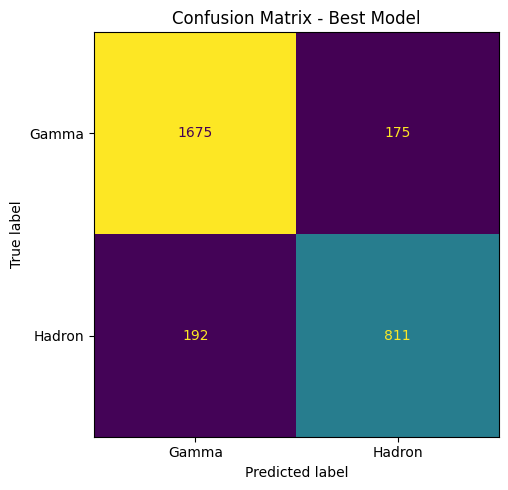

In [19]:

# SECTION: CONFUSION MATRIX

print("\n" + "=" * 70)
print("SECTION O: CONFUSION MATRIX")
print("=" * 70)

# Create confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Gamma", "Hadron"]
).plot(ax=ax, colorbar=False)

plt.title("Confusion Matrix - Best Model")
plt.tight_layout()
plt.savefig("plots/best_model_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

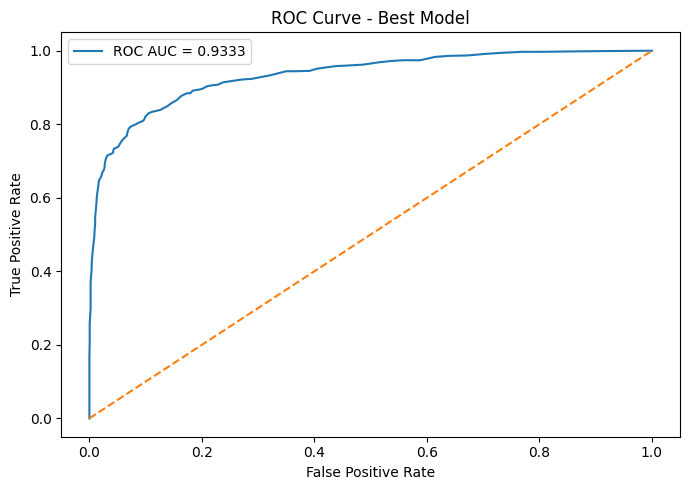

In [20]:

# SECTION P: ROC CURVE

# Calculate ROC values
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc = roc_auc_score(y_test, y_test_prob)

# Plot ROC Curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC AUC = {roc_auc:.4f}"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Model")
plt.legend()

plt.tight_layout()
plt.savefig("plots/best_model_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()


SECTION Q: PRECISION RECALL CURVE


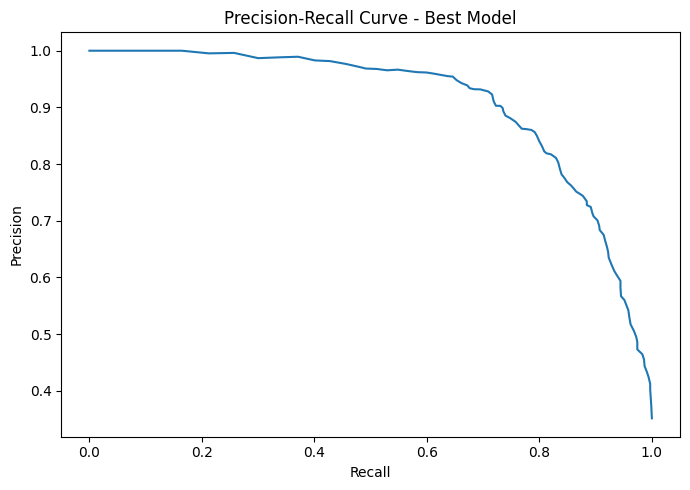

In [21]:
# ============================================================
# SECTION Q: PRECISION RECALL CURVE
# ============================================================

print("\n" + "=" * 70)
print("SECTION Q: PRECISION RECALL CURVE")
print("=" * 70)

# Calculate precision-recall values
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_prob)

# Plot Precision-Recall Curve
plt.figure(figsize=(7, 5))

plt.plot(recall_vals, precision_vals)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Best Model")

plt.tight_layout()
plt.savefig("plots/best_model_precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
import shutil
from google.colab import files

shutil.make_archive("plots", "zip", "plots")
files.download("plots.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>